# 5. Oligoset Generation

The final step in designing oligos is to organize them into optimal sets that maximize experimental efficiency and reliability. This step evaluates individual oligos, groups them into sets of non-overlapping oligos and ranks the sets by their overall efficiency scores. The `OligosetGenerator` ensures that only the best-performing sets of oligos are selected for downstream experimental use.

## Key Objectives in Oligoset Generation

- **Scoring Individual Oligos:** Each oligo is assigned a score based on its theoretical efficiency in the experimental context. Scores are computed using a class derived from `OligoScoringBase`. A list of implemented oligo scores is available [here](https://oligo-designer-toolsuite.readthedocs.io/en/latest/_api_docs/oligo_designer_toolsuite.oligo_efficiency_filter.html).
- **Scoring Oligo Sets:** Once individual oligos are scored, they are grouped into sets of oligos based on a set generator. A scoring class derived from `SetScoringBase` evaluates the overall efficiency of each set. A list of implemented oligo scores is available [here](https://oligo-designer-toolsuite.readthedocs.io/en/latest/_api_docs/oligo_designer_toolsuite.oligo_efficiency_filter.html).
- **Generating Oligo Sets:** Oligos in each set can be selected based on their positional overlap (`OligosetGeneratorIndependentSet`) or the homogeneity of specified oligo properties (`HomogeneousPropertyOligoSetGenerator`).
- **Selection Policies:** The `OligoSelectionPolicy` classes define the strategy for selecting and optimizing non-overlapping oligo sets from a pool of candidates. These policies use greedy or graph-based approaches to navigate the large combinatorial space of possible oligo combinations. This ensures the generated sets meet experimental requirements while adhering to constraints like set size and distance between oligos.

In this tutorial we show how one can:

- [Score oligos](#scoring)

- [Generate non-everlapping sets with a graph-based approach](#generating-oligosets)

- [Get ready-to-use oligo sets](#output-structure)


## Imports and setup

In [1]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from Bio.SeqUtils import MeltingTemp as mt

from oligo_designer_toolsuite.database import (
    OligoDatabase, OligoAttributes
)
from oligo_designer_toolsuite.oligo_efficiency_filter import (
    LowestSetScoring,
    IsoformConsensusScorer,
    NormalizedDeviationFromOptimalTmScorer,
    NormalizedDeviationFromOptimalGCContentScorer,
    OligoScoring
)

from oligo_designer_toolsuite.oligo_selection import (
    GraphBasedSelectionPolicy,
    OligosetGeneratorIndependentSet,
)

In [2]:
dir_output = os.path.abspath("./results")
Path(dir_output).mkdir(parents=True, exist_ok=True)

n_jobs = 3

In [3]:
# parameters
oligo_Tm_opt = 65
oligo_GC_content_opt = 50
oligo_isoform_weight = 2
oligo_Tm_weight = 1
oligo_GC_weight = 1

pre_filter = False 
n_attempts = 100000
heuristic = True
heuristic_n_attempts = 100
clique_init_approximation = False

max_graph_size = 5000
distance_between_oligos = 0

oligo_size_opt = 5
oligo_size_min = 3
n_sets = 100

oligo_GC_content_min = 40
oligo_GC_content_max = 60

oligo_Tm_min = 60 
oligo_Tm_max = 70 

Tm_parameters_oligo = {
    "nn_table": "DNA_NN3", # Allawi & SantaLucia (1997)
    "tmm_table": "DNA_TMM1", #default
    "imm_table": "DNA_IMM1", #default
    "de_table": "DNA_DE1", #default
    "dnac1": 50, #[nM]
    "dnac2": 0, #[nM]
    "saltcorr": 7, # Owczarzy et al. (2008)
    "Na": 39, #[mM]
    "K": 75, #[mM]
    "Tris": 20, #[mM]
    "Mg": 10, #[mM]
    "dNTPs": 0, #[mM] default
}
Tm_parameters_oligo["nn_table"] = getattr(mt, Tm_parameters_oligo["nn_table"])
Tm_parameters_oligo["tmm_table"] = getattr(mt, Tm_parameters_oligo["tmm_table"])
Tm_parameters_oligo["imm_table"] = getattr(mt, Tm_parameters_oligo["imm_table"])
Tm_parameters_oligo["de_table"] = getattr(mt, Tm_parameters_oligo["de_table"])

Tm_chem_correction_param_oligo = {
    "DMSO": 0, #default
    "fmd": 20,
    "DMSOfactor": 0.75, #default
    "fmdfactor": 0.65, #default
    "fmdmethod": 1, #default
    "GC": None, #default
}

### Load the database
Like in previous tutorials, we will also be working with `OligoDatabase` objects. If you don't know how they work, please check our [oligo database tutorial](2-oligo-database.ipynb). In this tutorial, we will load an existing database.

In [ ]:
# Create Database object
min_oligos_per_region = 3
write_regions_with_insufficient_oligos = True
max_entries_in_memory=n_jobs * 2 + 2
database_name="db_oligos"

oligo_database = OligoDatabase(
    min_oligos_per_region=min_oligos_per_region, 
    write_regions_with_insufficient_oligos=write_regions_with_insufficient_oligos, 
    max_entries_in_memory=max_entries_in_memory, 
    database_name=database_name, 
    dir_output=dir_output, 
    n_jobs=n_jobs,
)

# Load Database
dir_database = os.path.abspath("./data/3_db_oligos_specificity_filter")
oligo_database.load_database(dir_database=dir_database, database_overwrite=True, merge_databases_on_sequence_type="oligo")

Output()

Below we show the table of oligos for region *AARS1*, where we computed oligo attributes like melting temperature and GC content for each oligo.   
We can compare it later with the oligos that are kept after the set selection.

In [5]:
oligo_attribute_calculator = OligoAttributes()
oligo_database = oligo_attribute_calculator.calculate_GC_content(oligo_database=oligo_database)
oligo_database = oligo_attribute_calculator.calculate_TmNN(
    oligo_database=oligo_database, 
    Tm_parameters=Tm_parameters_oligo, 
    Tm_chem_correction_parameters=Tm_chem_correction_param_oligo, 
    Tm_salt_correction_parameters=None
)

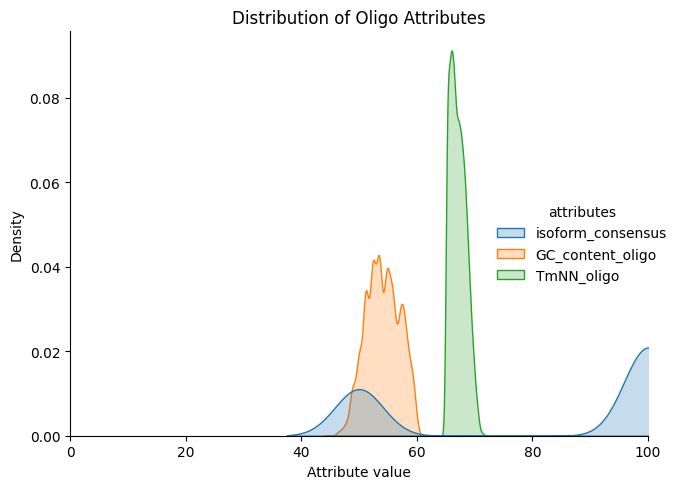

In [6]:
output_table = oligo_database.get_oligo_attribute_table(attributes=["oligo", "oligo_score", "isoform_consensus", "GC_content_oligo", "TmNN_oligo"], flatten=True, region_ids="AARS1")
output_table_plot = output_table.melt(id_vars="oligo_id", value_vars=["isoform_consensus", "GC_content_oligo", "TmNN_oligo"], var_name="attributes", value_name="attribute_value")

sns.displot(data=output_table_plot, x="attribute_value", hue="attributes", kind="kde", fill=True)
plt.title("Distribution of Oligo Attributes")
plt.xlabel("Attribute value")
plt.xlim([0, 100])
plt.tight_layout()
plt.show()


## Scoring

Each oligo scorer is implemented as a class inheriting from the abstract base class `BaseScorer`. This ensures all scorer have a standardized `apply()` method, which takes an `OligoDatabase` object, `region_id` and `oligo_id` as input and returns the calculated score. The `OligoScoring` class takes one or multiple scorer as inputs, iterates through a given set of `region_ids` and applies each scorer to the oligos of that region. The individual scores are summed for each oligo.

In [7]:
# oligo scoring
isoform_scorer = IsoformConsensusScorer(normalize=True, score_weight=oligo_isoform_weight)
Tm_scorer = NormalizedDeviationFromOptimalTmScorer(
    Tm_min=oligo_Tm_min,
    Tm_opt=oligo_Tm_opt,
    Tm_max=oligo_Tm_max,    
    Tm_parameters=Tm_parameters_oligo,
    Tm_chem_correction_parameters=Tm_chem_correction_param_oligo, 
    Tm_salt_correction_parameters=None,
    score_weight=oligo_Tm_weight,
)
GC_scorer = NormalizedDeviationFromOptimalGCContentScorer(
    GC_content_min=oligo_GC_content_min,
    GC_content_opt=oligo_GC_content_opt,
    GC_content_max=oligo_GC_content_max,
    score_weight=oligo_GC_weight,
)
oligos_scoring = OligoScoring(scorers=[isoform_scorer, Tm_scorer, GC_scorer])

# set scoring
set_scoring = LowestSetScoring(ascending=True)

## Oligo Selection Policy

The `GraphBasedSelectionPolicy` uses the scoring strategies, defined above, to select sets of non-overlapping oligos that minimize the overall set score. Key features include:

**Pre-Filtering:** If `pre_filter=True`, oligos are pre-filtered before set selection, removing oligos that cannot form sets of at least `oligo_size_min` oligos. This improves performance for larger sets (e.g., oligo_size_min > 30) but can dramatically slow down small set selection (e.g., oligo_size_min < 30).

**Search for Initial Set:** The graph-based set selection approach starts with finding an inital set of oligos which fulfills the minimum requirements, i.e. having a size of at least `oligo_size_min`. If no initial set is found, the selection step is terminated for the respective region. If an initial set is found, this set is used as starting point for selecting optimal sets by minimizing the overall set score. For larger sets (e.g., oligo_size_min > 15) the prformance improves when we use an approximation that finds the largest non-overlapping set in the graph using `clique_init_approximation=True`, however, if the set size is small (e.g., oligo_size_min < 15) it is more efficient to iterate through all possible non-overlapping sets by setting `clique_init_approximation=False`.

**Heuristic Search:** A heuristic approach is employed to optimize set selection within a feasible runtime:

- `heuristic`: Enables or disables heuristic optimization for faster results, which might not find the best possible set.
- `heuristic_n_attempts`: Maximum number of attempts to find optimal sets.

### Generating Oligosets

Using the `OligosetGeneratorIndependentSet`, the pipeline generates non-overlapping sets of oligos. The generator uses the scoring strategies and selection policies to create optimal sets of a user-defined size.

**Set Parameters:**

- `set_size_opt`: Optimal number of oligos per set.
- `set_size_min`: Minimum number of oligos required for a set.
- `n_sets`: Number of sets to generate.

**Graph Constraints:**

- `max_graph_size`: Limits the size of the graph for feasible computation.
- `distance_between_oligos`: Ensures no overlap between selected oligos.

**Note:** If `min_set_size` is set to a large value, consider switching from the graph-based selection policy to the `GreedySelectionPolicy`, as it increases the likelihood of finding large sets. However, keep in mind that the greedy approach may yield lower-scoring sets compared to the graph-based method.

In [8]:
selection_policy = GraphBasedSelectionPolicy(
    set_scoring=set_scoring,
    pre_filter=pre_filter,
    n_attempts=n_attempts,
    heuristic=heuristic,
    heuristic_n_attempts=heuristic_n_attempts,
    clique_init_approximation=clique_init_approximation,
)
probeset_generator = OligosetGeneratorIndependentSet(
    selection_policy=selection_policy,
    oligos_scoring=oligos_scoring,
    set_scoring=set_scoring,
    max_oligos=max_graph_size,
    distance_between_oligos=distance_between_oligos,
)

In [9]:
oligo_database = probeset_generator.apply(
    oligo_database=oligo_database,
    sequence_type="oligo",
    set_size_opt=oligo_size_opt,
    set_size_min=oligo_size_min,
    n_sets=n_sets,
    n_jobs=n_jobs,
)

# Save Database
dir_database = "4_db_oligoset_selection"
oligo_database.save_database(name_database=dir_database)

Output()

'/Users/lisasousa/Desktop/odt_projects/oligo-designer-toolsuite/tutorials/results/db_oligos/4_db_oligoset_selection'

### Output Structure

The generated sets are saved in a pandas DataFrame with the following structure:

 oligoset_id | oligo_0  | oligo_1  | oligo_2  |  ...  | oligo_n  | set_score_1 | set_score_2 |  ...  
------------ | -------- | -------- | -------- | ----- | -------- | ----------- | ----------- | ------:
 0           | AGRN_184 | AGRN_133 | AGRN_832 |  ...  | AGRN_706 | 0.3445      | 1.2332      |  ...  

- **oligoset_id**: Identifies each oligo set.
- **oligo_0, oligo_1, ...**: Oligos in the set.
- **set_score_***: Scores representing the set's efficiency.

In [10]:
# Show oligosets for a specific gene
oligo_database.oligosets["AARS1"]

,oligoset_id,oligo_0,oligo_1,oligo_2,oligo_3,oligo_4,set_score_worst,set_score_sum
0,0,AARS1::2291,AARS1::10497,AARS1::14964,AARS1::12911,AARS1::11384,0.01,0.030
1,1,AARS1::10497,AARS1::2290,AARS1::14964,AARS1::13103,AARS1::1780,0.01,0.030
2,2,AARS1::10497,AARS1::2291,AARS1::14964,AARS1::13103,AARS1::1780,0.01,0.030
3,3,AARS1::10497,AARS1::2255,AARS1::14964,AARS1::13103,AARS1::1780,0.01,0.032
4,4,AARS1::10497,AARS1::2256,AARS1::14964,AARS1::13103,AARS1::1780,0.01,0.032
5,5,AARS1::10497,AARS1::14964,AARS1::13103,AARS1::1780,AARS1::11384,0.01,0.038


We can now inspect the selected oligos below. The table shows that the selected oligos all have an isoform conses of 100% (i.e. covering all isoforms), have a GC content which equal the optimal GC content and a melting temperature very close to the optimal melting temperature.

In [11]:
output_table = oligo_database.get_oligo_attribute_table(attributes=["start", "end", "oligo", "oligo_score", "isoform_consensus", "GC_content_oligo", "TmNN_oligo"], flatten=True, region_ids="AARS1")
output_table.sort_values(by="start")

,region_id,oligo_id,start,end,oligo,oligo_score,isoform_consensus,GC_content_oligo,TmNN_oligo
4,AARS1,AARS1::2291,70261065,70261108,CTGATCCCCCACTTTCAGGTCACCGTAGATGGTTCCAATGTGTA,0.002,100.0,50.0,65.01
3,AARS1,AARS1::2290,70261066,70261109,TGATCCCCCACTTTCAGGTCACCGTAGATGGTTCCAATGTGTAG,0.002,100.0,50.0,65.01
2,AARS1,AARS1::2256,70261100,70261143,CAATGTGTAGCACATACCCTCCTCGGACCTGAGCATTCTTCACT,0.004,100.0,50.0,65.02
1,AARS1,AARS1::2255,70261101,70261144,AATGTGTAGCACATACCCTCCTCGGACCTGAGCATTCTTCACTG,0.004,100.0,50.0,65.02
0,AARS1,AARS1::1780,70262378,70262421,AGCCTTCGTCATAGATCTGGCCTCCTTGCTCAGCATAGAAACAG,0.010,100.0,50.0,65.05
9,AARS1,AARS1::14964,70267764,70267805,CCTTCACCATGTCTGGGTCCTTCTTCAGCTCAGGAAATGCAT,0.006,100.0,50.0,65.03
8,AARS1,AARS1::13103,70270282,70270321,GGCCCATCCCTGTGTCAATGCTTTTCTTGGGAAGAGGTTT,0.010,100.0,50.0,65.05
7,AARS1,AARS1::12911,70271805,70271848,TTCCAGATCTCCAGCACATTAGGGTCGTCCTGGTTGACAAGATG,0.010,100.0,50.0,65.05
6,AARS1,AARS1::11384,70276990,70277033,AGAGCCCAGCATCTCGAAGAAGGTGTGATGATAGACATCCTTGC,0.010,100.0,50.0,65.05
5,AARS1,AARS1::10497,70282670,70282713,TGGTGGCAGACGAGTGAACATACGTATGCTCGTTCCTCTTGAAG,0.002,100.0,50.0,65.01


Applying set selection to the OligoDatabase is critical for several reasons:

- **Ensures Experimental Efficiency:** Generates sets of high-scoring oligos, ensuring effective target binding without competition.
- **Customizable and Scalable:** Users can tailor scoring strategies and selection policies to meet specific experimental needs.
- **Optimized Workflow:** Pre-filtering approaches and heuristic methods enable efficient generation of high-quality oligosets, even for large datasets.

This step finalizes the pipeline by providing optimal, ready-to-use oligosets tailored to experimental requirements. These sets can then be directly integrated into downstream experimental protocols.